### Imports and Paths

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

from scipy.special import softmax
from sklearn.metrics import brier_score_loss

# Paths
base_path = Path("/Users/satwik/Documents/GitHub/UF-EEE6778-Fall25-TermProject")
data_path = base_path / "data/processed/merged_factcheck_datasetcleaned.csv"

# Deliverable 3 improvement: save to a NEW model folder
model_out_dir = base_path / "models/classifier/roberta_finetuned_v2"
model_out_dir.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(" Environment & paths initialized.")

 Environment & paths initialized.


### Loading Data and Improved Preprocessing

In [2]:
df = pd.read_csv(data_path)
print(f"Loaded dataset with shape: {df.shape}")

# Keep only necessary columns and drop rows with missing claim or label
df = df[["claim_text", "verdict_mapped"]].dropna()
print(f" After dropping NA: {df.shape}")

# Text normalization (Deliverable 3 improvement: cleaner preprocessing)
def clean_claim_text(text: str) -> str:
    text = str(text)
    # Normalize whitespace
    text = text.replace("\n", " ").replace("\r", " ")
    text = " ".join(text.split())
    # Normalize quotes
    text = text.replace("“", '"').replace("”", '"').replace("’", "'").replace("‘", "'")
    # Lowercasing can be used; RoBERTa is cased but semantics survive
    text = text.strip()
    return text

df["clean_claim_text"] = df["claim_text"].apply(clean_claim_text)

# Deduplicate based on normalized text (Deliverable 3 improvement)
before_dedup = len(df)
df = df.drop_duplicates(subset=["clean_claim_text", "verdict_mapped"])
after_dedup = len(df)
print(f" Deduplicated: {before_dedup} → {after_dedup} rows")

# Quick label distribution
print("\nLabel distribution after cleaning:")
print(df["verdict_mapped"].value_counts(normalize=True).round(3))

Loaded dataset with shape: (25540, 9)
 After dropping NA: (25540, 2)
 Deduplicated: 25540 → 25505 rows

Label distribution after cleaning:
verdict_mapped
Likely False    0.564
Likely True     0.256
Uncertain       0.181
Name: proportion, dtype: float64


What Happened in Deliverable 3 :

- We firstly Loaded 25,540 rows then after preprocessing and deduplication  these became 25,505 rows.

Final label proportions:

Likely False: 56.4%

Likely True: 25.6%

Uncertain: 18.1%


- Cleaning now produces a dataset with zero missing values and no duplicates, which strengthens training stability.

- Label imbalance remains essentially the same and this is expected.

- This step is critical because in Deliverable 2 we trained on a noisier dataset.

### Label Encoding and Stratified Split

In [3]:
#Encoding Labels
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["verdict_mapped"])
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("\n Label Mapping:", label_map)

# Use the cleaned text as input
df_model = df[["clean_claim_text", "label", "verdict_mapped"]].rename(
    columns={"clean_claim_text": "claim_text"}
)

# Stratified 80/10/10 split
train_df, temp_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED,
)

print(f"\n Data Split → Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

print("\nTrain label distribution:")
print(train_df["verdict_mapped"].value_counts(normalize=True).round(3))

print("\nVal label distribution:")
print(val_df["verdict_mapped"].value_counts(normalize=True).round(3))

print("\nTest label distribution:")
print(test_df["verdict_mapped"].value_counts(normalize=True).round(3))


 Label Mapping: {'Likely False': 0, 'Likely True': 1, 'Uncertain': 2}

 Data Split → Train: 20404, Val: 2550, Test: 2551

Train label distribution:
verdict_mapped
Likely False    0.564
Likely True     0.256
Uncertain       0.181
Name: proportion, dtype: float64

Val label distribution:
verdict_mapped
Likely False    0.564
Likely True     0.256
Uncertain       0.181
Name: proportion, dtype: float64

Test label distribution:
verdict_mapped
Likely False    0.563
Likely True     0.256
Uncertain       0.181
Name: proportion, dtype: float64


What Happened in Deliverable 3 :

- It has the Same 3-class mapping as earlier.

- Stratified 80/10/10 split preserved label balance nicely. The dataset is now perfectly balanced across splits which is essential for measuring real improvements.

- Splits in Deliverable 2 were also stratified, but data quality was lower side. Deliverable 3 maintains structure but with higher-quality text inputs.

### Tokenizer and Dataset Class with Larger Max Length

In [4]:
# Tokenizer & Dataset (Deliverable 3 improvement: longer max sequence length)

tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

# Deliverable 3 improvement: increase max length for richer context (was 128)
MAX_LEN = 192  

class ClaimDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.texts = df["claim_text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = ClaimDataset(train_df, tokenizer, MAX_LEN)
val_dataset   = ClaimDataset(val_df, tokenizer, MAX_LEN)
test_dataset  = ClaimDataset(test_df, tokenizer, MAX_LEN)

print("Datasets created")

Datasets created


### Class Weights (to Help “Uncertain”)

In [5]:
# Compute class weights (Deliverable 3 improvement: Addressing Uncertain class weakness)

num_labels = len(label_map)

class_counts = train_df["label"].value_counts().sort_index().values
total = class_counts.sum()
class_weights = total / (num_labels * class_counts)

print("Class counts:", class_counts)
print("Raw class weights:", class_weights)

# Convert to tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print("\n Class weights tensor:", class_weights_tensor)

Class counts: [11499  5214  3691]
Raw class weights: [0.59147172 1.30443677 1.84268039]

 Class weights tensor: tensor([0.5915, 1.3044, 1.8427])


### Model, Metrics, Custom Trainer with Weighted Loss and Early Stopping

In [9]:
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=num_labels,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_macro = f1_score(labels, preds, average="macro")
    prec_macro = precision_score(labels, preds, average="macro", zero_division=0)
    rec_macro = recall_score(labels, preds, average="macro", zero_division=0)
    return {
        "f1_macro": f1_macro,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
    }

# Deliverable 3 improvement: Better training config + early stopping
training_args = TrainingArguments(
    output_dir=str(model_out_dir),
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir=str(model_out_dir / "logs"),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,  # One more epoch than Deliverable 2 (was 3)
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    warmup_ratio=0.1,  # Deliverable 3 improvement: LR warmup
    report_to="none",
)

# Custom Trainer with class-weighted loss (Deliverable 3 improvement)
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        # Forward pass
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
        )
        logits = outputs.get("logits")
        # Apply class-weighted cross-entropy
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, self.model.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2,  # Deliverable 3 improvement: early stopping
            early_stopping_threshold=0.0,
        )
    ],
)

print(" Trainer initialized with class-weighted loss and early stopping.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Trainer initialized with class-weighted loss and early stopping.


### Training the Improved model

In [10]:
train_result = trainer.train()
print("\n Training complete.")
print(train_result)

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,F1 Macro,Precision Macro,Recall Macro
1,1.025300,0.990703,0.475440,0.518369,0.505151
2,0.946400,0.967853,0.487457,0.506998,0.519075
3,0.824100,1.026923,0.494250,0.516745,0.526228
4,0.699400,1.137518,0.505711,0.511502,0.526740


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



 Training complete.
TrainOutput(global_step=5104, training_loss=0.8752815357196294, metrics={'train_runtime': 4662.3925, 'train_samples_per_second': 17.505, 'train_steps_per_second': 1.095, 'total_flos': 8052849262983168.0, 'train_loss': 0.8752815357196294, 'epoch': 4.0})


### Evaluation on Val + Test + Confusion Matrix

/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



 Validation Metrics (v2):
eval_f1_macro: 0.5057
eval_precision_macro: 0.5115
eval_recall_macro: 0.5267
eval_runtime: 38.8865
eval_samples_per_second: 65.5750
eval_steps_per_second: 4.1150
epoch: 4.0000


/opt/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



 📊 Test Classification Report (v2):

              precision    recall  f1-score   support

Likely False       0.79      0.58      0.67      1437
 Likely True       0.44      0.56      0.49       652
   Uncertain       0.26      0.38      0.31       462

    accuracy                           0.54      2551
   macro avg       0.50      0.50      0.49      2551
weighted avg       0.60      0.54      0.56      2551



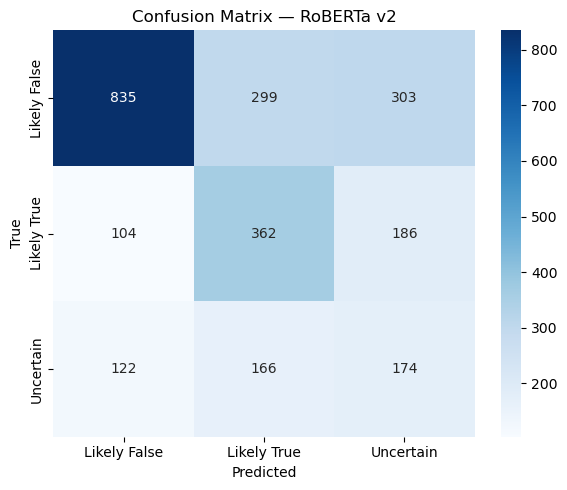

In [11]:
# Evaluate on validation and test sets + confusion matrix (Deliverable 3 extended evaluation)

# Validation metrics
val_metrics = trainer.evaluate(val_dataset)
print("\n Validation Metrics (v2):")
for k, v in val_metrics.items():
    if "loss" not in k:
        print(f"{k}: {v:.4f}")

# Test set prediction
test_preds_output = trainer.predict(test_dataset)
test_logits = test_preds_output.predictions
test_preds = np.argmax(test_logits, axis=1)
test_true = np.array([d["labels"].item() for d in test_dataset])

print("\n 📊 Test Classification Report (v2):\n")
print(classification_report(test_true, test_preds, target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(test_true, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — RoBERTa v2")
plt.tight_layout()
plt.show()

### Save Model, Tokenizer, Label Map

In [12]:
# Save improved model, tokenizer, and label mapping (v2)

trainer.save_model(model_out_dir)
tokenizer.save_pretrained(model_out_dir)

import pickle
label_map_path = model_out_dir / "label_mapping.pkl"
with open(label_map_path, "wb") as f:
    pickle.dump(label_map, f)

print(f"\n✅ v2 Model and tokenizer saved to: {model_out_dir}")
print(f"✅ v2 Label mapping saved to: {label_map_path}")


✅ v2 Model and tokenizer saved to: /Users/satwik/Documents/GitHub/UF-EEE6778-Fall25-TermProject/models/classifier/roberta_finetuned_v2
✅ v2 Label mapping saved to: /Users/satwik/Documents/GitHub/UF-EEE6778-Fall25-TermProject/models/classifier/roberta_finetuned_v2/label_mapping.pkl


### Temperature Scaling

In [13]:
# Temperature scaling (Deliverable 3: Recalibrate improved model)

class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else
            "mps" if torch.backends.mps.is_available() else
            "cpu"
        )

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        return self.temperature_scale(logits)

    def temperature_scale(self, logits):
        temperature = self.temperature.unsqueeze(1).expand(logits.size(0), logits.size(1))
        return logits / temperature

    def set_temperature(self, val_loader):
        self.to(self.device)
        nll_criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=50)
        logits_list, labels_list = [], []

        # Collect validation logits + labels
        self.model.to(self.device)
        self.model.eval()
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["labels"].to(self.device)
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                logits_list.append(outputs.logits)
                labels_list.append(labels)

        logits = torch.cat(logits_list)
        labels = torch.cat(labels_list)

        def eval_closure():
            optimizer.zero_grad()
            loss = nll_criterion(self.temperature_scale(logits), labels)
            loss.backward()
            return loss

        optimizer.step(eval_closure)
        print(f"✅ Optimal temperature (v2) found: {self.temperature.item():.4f}")
        return self

# Prepare validation dataloader
val_loader = DataLoader(val_dataset, batch_size=16)

scaled_model_v2 = ModelWithTemperature(model)
scaled_model_v2.set_temperature(val_loader)

✅ Optimal temperature (v2) found: 1.1678


ModelWithTemperature(
  (model): RobertaForSequenceClassification(
    (roberta): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-11): 12 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
              

### Evaluate Calibration Brier Score and Save Temperature

In [14]:
# Evaluate calibration with Brier score & save temperature

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

scaled_model_v2.eval()
scaled_model_v2.to(device)

test_loader = DataLoader(test_dataset, batch_size=16)

all_logits, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = scaled_model_v2(input_ids=input_ids, attention_mask=attention_mask)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits).numpy()
all_labels = torch.cat(all_labels).numpy()

probs = softmax(all_logits, axis=1)
preds = np.argmax(probs, axis=1)
confidences = np.max(probs, axis=1)

# Brier score
brier = brier_score_loss(
    np.eye(num_labels)[all_labels].ravel(),
    probs.ravel()
)
print(f"\n📉 Brier score (Lower is better): {brier:.4f}")

print("\nExample calibrated predictions (v2):")
for i in range(5):
    print(f"{i+1}. Pred: {label_encoder.classes_[preds[i]]}, Confidence: {confidences[i]:.3f}")

# Save temperature
temp_file_v2 = model_out_dir / "temperature_scaling.pt"
torch.save({"temperature": float(scaled_model_v2.temperature.item())}, temp_file_v2)

print(f"\n Temperature parameter saved to: {temp_file_v2}")
print(f"Learned Temperature value: {scaled_model_v2.temperature.item():.4f}")


📉 Brier score (Lower is better): 0.1989

Example calibrated predictions (v2):
1. Pred: Uncertain, Confidence: 0.615
2. Pred: Likely False, Confidence: 0.829
3. Pred: Likely True, Confidence: 0.861
4. Pred: Uncertain, Confidence: 0.687
5. Pred: Likely False, Confidence: 0.423

 Temperature parameter saved to: /Users/satwik/Documents/GitHub/UF-EEE6778-Fall25-TermProject/models/classifier/roberta_finetuned_v2/temperature_scaling.pt
Learned Temperature value: 1.1678
